In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

In [7]:
# --- Load eval JSON ---

# No occasion ablation results - scores sin softmax 
# EVAL_PATH = "results/ablation_no_occasion/eval_20260324_104855.json"  

# Top 5 complete results (not first run) - scores with softmax too little 
EVAL_PATH = "results/top5complete_results/(0.4-0.6 weights) eval_20260324_132211.json"


with open(EVAL_PATH) as f:
    data = json.load(f)

print(f"Loaded {data['total_queries']} queries from {data['run_timestamp']}")

Loaded 50 queries from 20260324_132211


In [8]:
# --- Extract occasion_appropriateness scores per model ---
MODEL_KEYS = [k for k in data["per_query"][0]["eval"] if "items" in data["per_query"][0]["eval"].get(k, {})]
print("Models with item-level evals:", MODEL_KEYS)

records = []
for q in data["per_query"]:
    qid = q["id"]
    query_text = q["query"]
    for model in MODEL_KEYS:
        for i, item in enumerate(q["eval"][model]["items"]):
            occ = item.get("occasion_appropriateness", {})
            records.append({
                "query_id": qid,
                "query": query_text,
                "model": model,
                "item_idx": i,
                "occasion_score": occ.get("score"),
                "reasoning": occ.get("reasoning", ""),
            })

df = pd.DataFrame(records)
print(f"{len(df)} total item-level scores")
df.head()

Models with item-level evals: ['clip', 'fashion_clip', 'random']
750 total item-level scores


,query_id,query,model,item_idx,occasion_score,reasoning
0,q101,I need something elegant for my friend's weddi...,clip,0,NaN,No occasion specified
1,q101,I need something elegant for my friend's weddi...,clip,1,NaN,No occasion specified
2,q101,I need something elegant for my friend's weddi...,clip,2,NaN,No occasion specified
3,q101,I need something elegant for my friend's weddi...,clip,3,NaN,No occasion specified
4,q101,I need something elegant for my friend's weddi...,clip,4,NaN,No occasion specified


In [9]:
# --- Count table per model ---
score_range = sorted(df["occasion_score"].dropna().unique())
counts = df.groupby(["model", "occasion_score"]).size().unstack(fill_value=0)
counts = counts.reindex(columns=score_range, fill_value=0)
counts["total"] = counts.sum(axis=1)
print("Occasion Appropriateness Score Counts by Model")
counts

Occasion Appropriateness Score Counts by Model


occasion_score,1.0,2.0,3.0,4.0,5.0,total
model,,,,,,
clip,0,7,54,99,25,185
fashion_clip,0,5,38,102,40,185
random,28,86,50,20,1,185


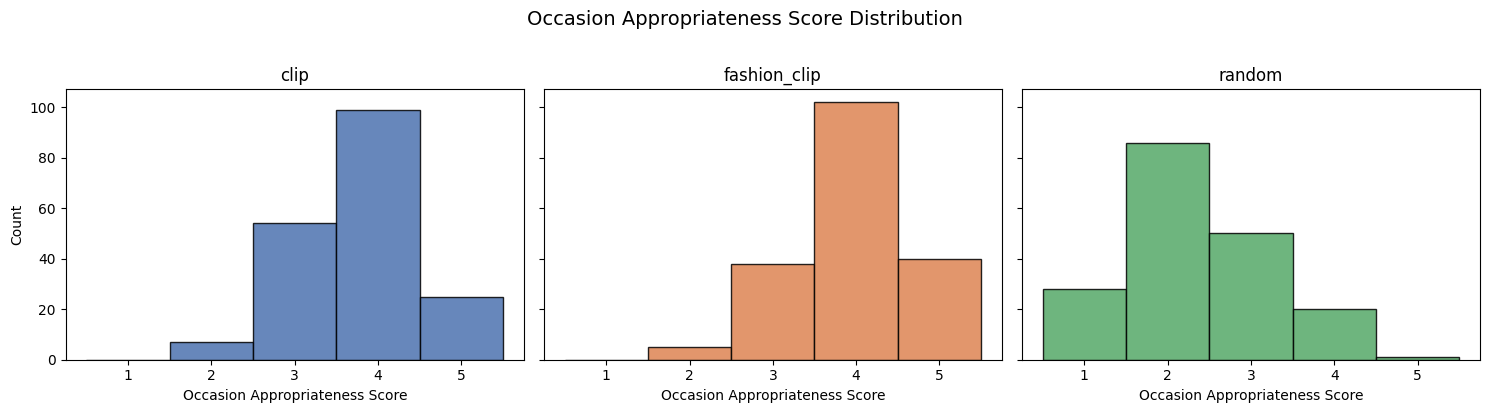

In [10]:
# --- Histogram ---
fig, axes = plt.subplots(1, len(MODEL_KEYS), figsize=(5 * len(MODEL_KEYS), 4), sharey=True)
if len(MODEL_KEYS) == 1:
    axes = [axes]

colors = {"clip": "#4C72B0", "fashion_clip": "#DD8452", "random": "#55A868"}

for ax, model in zip(axes, MODEL_KEYS):
    subset = df[df["model"] == model]["occasion_score"].dropna()
    ax.hist(subset, bins=[s - 0.5 for s in score_range] + [score_range[-1] + 0.5],
            color=colors.get(model, "#999999"), edgecolor="black", alpha=0.85)
    ax.set_title(model)
    ax.set_xlabel("Occasion Appropriateness Score")
    ax.set_xticks(score_range)

axes[0].set_ylabel("Count")
fig.suptitle("Occasion Appropriateness Score Distribution", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()